<a href="https://colab.research.google.com/github/sgaleanoca/Senales_y_Sistemas/blob/parcial_primer_corte/Parcial_1_SyS_Demostraciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Parcial 1

## **Programación**

El ejercicio nos pide muestrear la siguiente señal:

$x(t)=Acos(7t)$

ti=0

tf=2


### **Versión 1 - Original e incorrecta**

**¿Qué hace np.arange(ti, tf, T)?**

La función arange genera números comenzando en ti hasta tf, con pasos de tamaño T:

    Toma el primer punto en t=0

    Toma el último punto en t=2

    Avanza en períodos de T= 0.9s

Pasa que en este código se usa el T en la linea del "np.arange", porque ese está tomando la muestra exactamente cada vez que la onda vuelve al mismo punto de inicio.

Esto es incorrecto porque no se ve bien la señal.

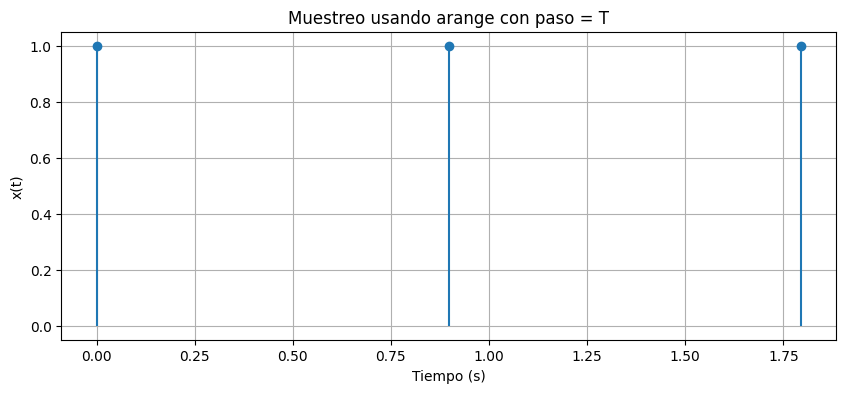

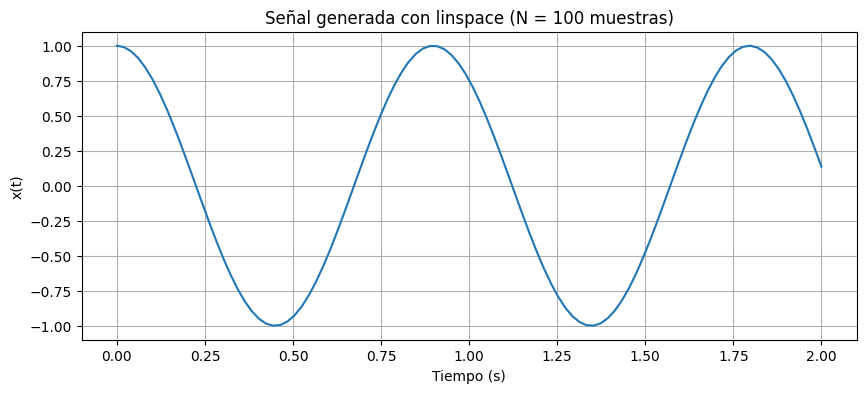

In [ ]:
# ========================================
# Aqui importamos las librerías
import numpy as np
import matplotlib.pyplot as plt
# ========================================

# ========================================
# Estos son los parámetros de la señal

A = 1                # Amplitud
w0 = 7               # Frecuencia angular
ti = 0               # Tiempo inicial
tf = 2               # Tiempo final
N = 100              # Número de muestras
# ========================================

# ========================================
# Aqui convertimos la frecuencia angular a frecuencia normal y periodo

f = w0 / (2 * np.pi)    # Frecuencia en Hz
T = 1 / f               # Periodo de la señal
# ========================================

# ========================================
# Vector de muestras discretas
# Usamos arange porque tenemos una frecuencia de muestreo específica

t_arange = np.arange(ti, tf, T)
x_arange = A * np.cos(w0 * t_arange)
# ========================================

# ========================================
# Aqui creamos el vector de tiempo con N muestras
# Usamos linspace porque queremos exactamente N puntos equiespaciados

t_linspace = np.linspace(ti, tf, N)
x_linspace = A * np.cos(w0 * t_linspace)
# ========================================

# ========================================
# Gráfica

# arange
plt.figure(figsize=(10,4))
plt.stem(t_arange, x_arange, basefmt=" ")
plt.title("Muestreo usando arange con paso = T")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

# linspace
plt.figure(figsize=(10,4))
plt.plot(t_linspace, x_linspace)
plt.title("Señal generada con linspace (N = 100 muestras)")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()
# ========================================

### **Versión 2 - Versión básica con Nyquist**

Aquí se muestran 2 diferencias:

- El código 1 tiene pocas muestras, revelando el Aliasing.

- El código 2 tiene muchas muestras, aplicando el teorema de Nyquist y respetandolo.

La razón por la que ocurre el Aliasing, es por muestrear tan poco.

**Por qué tienen que ser 100 muestras y no 20?**

El motivo es porque la señal se muestrea tan poco que parece más lenta, cuando en realidad es rápida


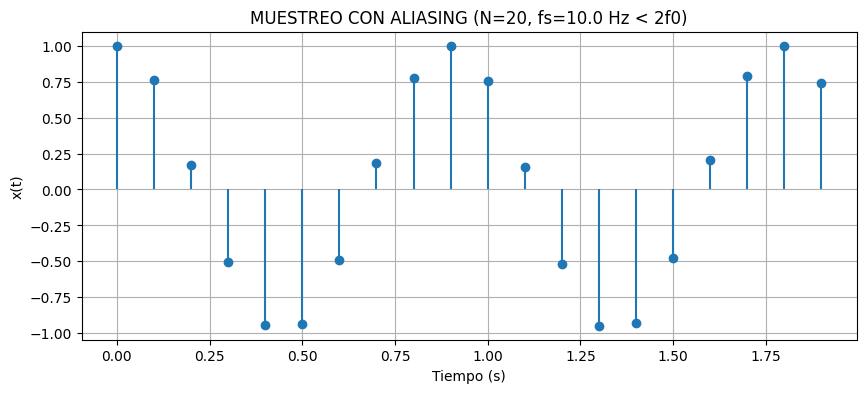

In [ ]:
# ========================================
# CODIGO 1: POCAS MUESTRAS - ALIASING
import numpy as np
import matplotlib.pyplot as plt
# ========================================

# ========================================
# Parámetros de la señal

A = 1                # Amplitud
w0 = 7               # Frecuencia angular
ti = 0               # Tiempo inicial
tf = 2               # Tiempo final
# ========================================

# ========================================
# Frecuencia real de la señal
# Aquí se calcula la frecuencia real de la señal

f0 = w0 / (2*np.pi)
# ========================================

# ========================================
# Elegimos pocas muestras para provocar aliasing

N1 = 20                       # Muy pocas muestras
fs1 = N1 / (tf - ti)          # fs = 10 Hz
Ts1 = 1 / fs1
# ========================================

# ========================================
# Generamos las muestras

t1 = np.arange(ti, tf, Ts1)
x1 = A * np.cos(w0 * t1)
# ========================================

# ========================================
# Gráfica

plt.figure(figsize=(10,4))
plt.stem(t1, x1, basefmt=" ")
plt.title(f"MUESTREO CON ALIASING (N={N1}, fs={fs1} Hz < 2f0)")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()
# ========================================


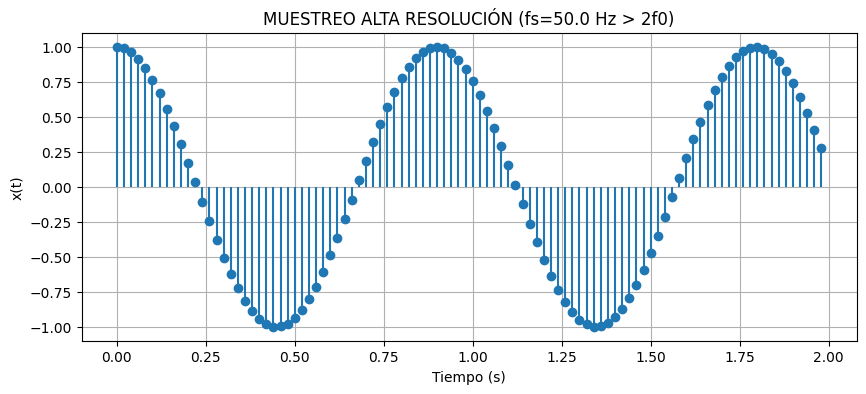

In [ ]:
# =======================================
# CODIGO 2: ALTA RESOLUCIÓN SIN ALIASING
import numpy as np
import matplotlib.pyplot as plt
# =======================================

# =======================================
# Parámetros de la señal

A = 1                # Amplitud
w0 = 7               # Frecuencia angular
ti = 0               # Tiempo inicial
tf = 2               # Tiempo final
# =======================================

# =======================================
# Frecuencia que respeta Nyquist
# Se usa arange porque tenemos una frecuencia de muestreo específica

N2 = 100                      # Muchas muestras
fs2 = N2 / (tf - ti)          # fs = 50 Hz
Ts2 = 1 / fs2
# =======================================

# =======================================
# Generamos las muestras

tm_arange = np.arange(ti, tf, Ts2)
xm_arange = A * np.cos(w0 * tm_arange)
# =======================================

# =======================================
# Gráfica

plt.figure(figsize=(10,4))
plt.stem(tm_arange, xm_arange, basefmt=" ")
plt.title(f"MUESTREO ALTA RESOLUCIÓN (fs={fs2} Hz > 2f0)")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()
# =======================================


### **Versión 3 - Versión con Linspace**

De por si, "linspace" no sirve para muestrear una señal físicamente, porque no usa frecuencia de muestreo.

Pero no importa si la frecuencia de la señal es 7 rad/s o 7000 rad/s, linspace no respeta nada. Por eso se ve estático.


**Para qué sirve entonces Linspace?**

- Para graficar señales continuas, como si fueran líneas suaves.

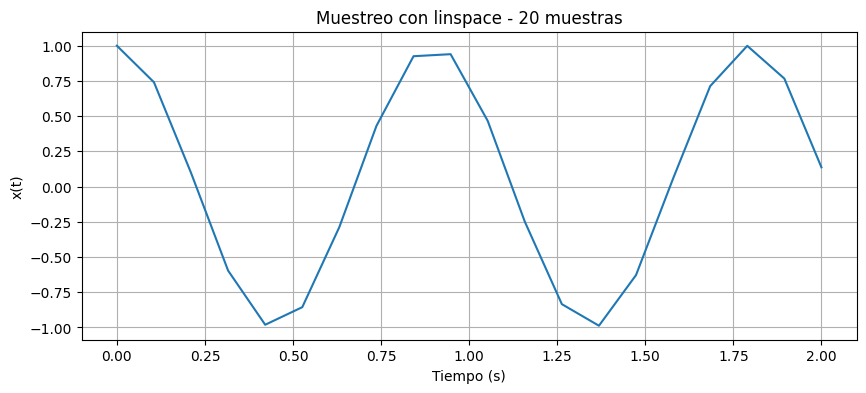

In [ ]:
# ========================================
# Aqui importamos las librerías

import numpy as np
import matplotlib.pyplot as plt
# ========================================

# ========================================
# Parametros de la señal

A = 1                # Amplitud
w0 = 7               # Frecuencia angular
ti = 0               # Tiempo inicial
tf = 2               # Tiempo final
# ========================================

"""# ========================================
# Frecuencia y periodo
# Aqui convertimos la frecuencia angular a frecuencia normal y periodo
fhz = w0 / (2 * np.pi)
T = 1 / fhz
# ========================================"""

# ========================================
# Vector de tiempo con linspace
# Ponemos 20 muestras para saber la gran diferencia

N = 20
tp_linspace = np.linspace(ti, tf, N)
xp_linspace = A * np.cos(w0 * tp_linspace)
# ========================================

# ========================================
# Gráfica

plt.figure(figsize=(10,4))
plt.plot(tp_linspace, xp_linspace)
plt.title("Muestreo con linspace - 20 muestras")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()
# ========================================


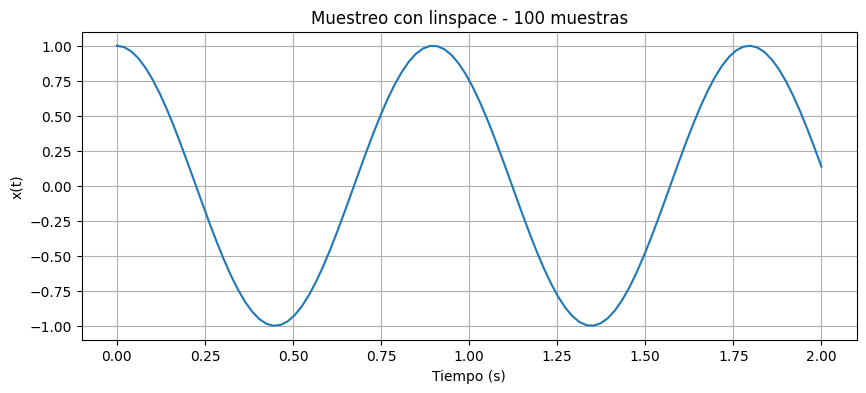

In [ ]:
# ========================================
# Aqui importamos las librerías

import numpy as np
import matplotlib.pyplot as plt
# ========================================

# ========================================
# Parametros de la señal

A = 1                # Amplitud
w0 = 7               # Frecuencia angular
ti = 0               # Tiempo inicial
tf = 2               # Tiempo final
# ========================================

"""# ========================================
# Frecuencia y periodo
# Aqui convertimos la frecuencia angular a frecuencia normal y periodo

fhz2 = w0 / (2 * np.pi)
T = 1 / fhz2
# ========================================"""

# ========================================
# Vector de tiempo y muestras
# Aqui se genera el vector de tiempo con linspace
NT = 100
tx_linspace = np.linspace(ti, tf, NT)
xn_linspace = A * np.cos(w0 * tx_linspace)
# ========================================

# ========================================
# Gráfica

plt.figure(figsize=(10,4))
plt.plot(tx_linspace, xn_linspace)
plt.title("Muestreo con linspace - 100 muestras")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()
# ========================================


### **Versión 4 - Código Nyquist + linspace**

Finalmente, después de haber visto las diferencias entre tener aliasing y no tener aliasing, se combina los códigos finales que tienen el teorema de Nyquist con arange y linspace.

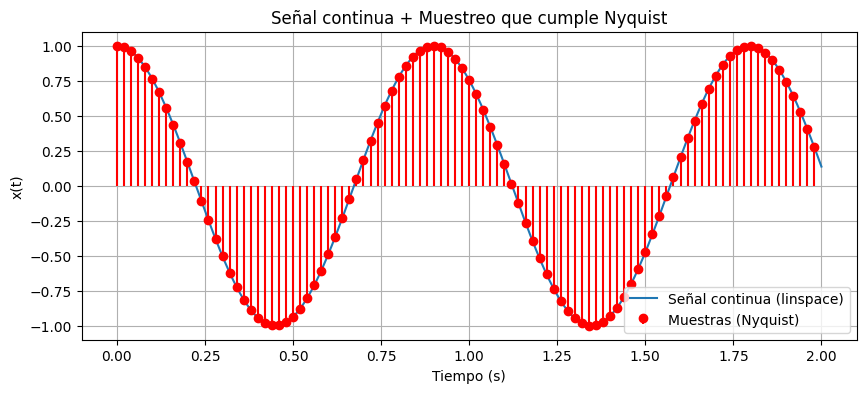

In [ ]:
# =======================================
# Codigo final: Nyquist + Señal continua con linspace

import numpy as np
import matplotlib.pyplot as plt
# =======================================

# =======================================
# Parámetros de la señal

A = 1                # Amplitud
w0 = 7               # Frecuencia angular
ti = 0               # Tiempo inicial
tf = 2               # Tiempo final
# =======================================

# =======================================
# Señal continua aproximada con linspace

N_cont = 1000          # Muchas muestras para ver la señal suave
t_cont = np.linspace(ti, tf, N_cont)
x_cont = A * np.cos(w0 * t_cont)
# =======================================

# =======================================
# Muestreo real que respeta Nyquist
# Aqui se calcula la frecuencia de muestreo real, y el periodo de muestreo.
# Como es una señal continua, se usa el teorema de Nyquist para calcular la frecuencia de muestreo y asi evitar el aliasing colocando muchas muestras.

N3 = 100                            # Número de muestras reales
fs3 = N3 / (tf - ti)                # Frecuencia de muestreo
Ts3 = 1 / fs3                       # Periodo de muestreo

t_samples = np.arange(ti, tf, Ts3)
x_samples = A * np.cos(w0 * t_samples)
# =======================================

# =======================================
# Gráfica combinada

plt.figure(figsize=(10,4))

# Señal continua
plt.plot(t_cont, x_cont, label="Señal continua (linspace)")

# Muestras reales Nyquist
plt.stem(t_samples, x_samples, basefmt=" ", linefmt='r-', markerfmt='ro', label="Muestras (Nyquist)")

plt.title("Señal continua + Muestreo que cumple Nyquist")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.grid(True)
plt.legend()

plt.show()
# =======================================


## Arrays



In [ ]:
import numpy as np

V = np.array([[4, 5, 6],
              [7, 8, 9]])

print(V[1,1])   # Esto imprime 8
print(V[:,0])   # Esto imprime [4 7]
print(V[1,2])   # Esto imprime 9
print(V[1,:])   # Esto imprime [7 8 9]

# print([1, 1]) → fila 1 / columna 1

# print([:, 0]) → todas las filas / columna 0 (dame toda la fila 0)

# print([1, 2]) → fila 1 / columna 2

# print([1, :]) → fila 1 / todas las columnas (dame toda la columna 0)

8
[4 7]
9
[7 8 9]


## Serie de Fourier - Simulación

La línea azul representa la señal original
La línea naranja representa la señal trigonométrica


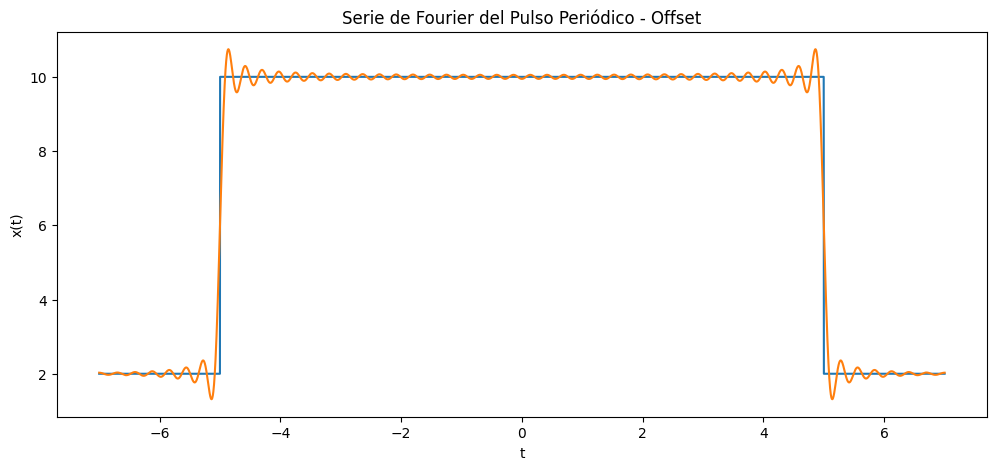

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETROS DE LA SEÑAL

A = 8        # amplitud del pulso
T = 14        # periodo
tau = 10      # duración del pulso (de -5 a 5)
w0 = 2*np.pi/T
# ============================================================

# ============================================================
# DEFINICIÓN DE LA SEÑAL X(t)

def x_original(t):
  t_mod = ((t + T/2) % T) - T/2
  # Le sumamos 2 al final para subir el "piso" de la señal
  return 2 + A * ((t_mod >= -tau/2) & (t_mod <= tau/2)) #Offset 2
# ============================================================

# ============================================================
# COEFICIENTES DE FOURIER (solo an, ya que bn=0 es par)

def a_n(n):
    if n == 0:
      # Usamos el Área Total (108) que calculamos a mano
      # a0 = (2/T) * Area_Total -> (2/14) * 108
      return 2 * (108 / T)

    # El resto queda igual (la parte del coseno/seno no cambia)
    return (2*A/(np.pi*n)) * np.sin( (5*np.pi*n)/7 )
# ============================================================

# ============================================================
# SERIE TRIGONOMÉTRICA

def x_reconstruida(t, N):
  suma = a_n(0)/2   # Término DC

  for n in range(1, N+1):
    suma += a_n(n) * np.cos(n * w0 * t)

  return suma
# ============================================================

# ============================================================
# SIMULACIÓN

# Malla de tiempo para graficar varias copias del periodo
# t = np.linspace(-16, 16, 5000)  # Varios periodos
t = np.linspace(-7, 7, 5000)      # Un solo periodo

# Señales
x_ref = x_original(t)
x_rec = x_reconstruida(t, N=50)
# ============================================================

# ============================================================
# GRAFICA

print("La línea azul representa la señal original")
print("La línea naranja representa la señal trigonométrica")
plt.figure(figsize=(12,5))
plt.plot(t, x_ref)
plt.plot(t, x_rec)
plt.title("Serie de Fourier del Pulso Periódico - Offset")
plt.xlabel("t")
plt.ylabel("x(t)")
#plt.grid(True)
plt.show()
# ============================================================

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETROS DE LA SEÑAL

A = 8        # amplitud del pulso (de 0 a 8)
T = 14       # periodo
tau = 10     # duración del pulso (de -5 a 5)
w0 = 2*np.pi/T
# ============================================================

# ============================================================
# DEFINICIÓN DE LA SEÑAL X(t)  sin offset

def x_original(t):
    t_mod = ((t + T/2) % T) - T/2
    # Se elimina el +2
    # Señal de 0 a 8
    return A * ((t_mod >= -tau/2) & (t_mod <= tau/2))
# ============================================================

# ============================================================
# COEFICIENTES DE FOURIER (solo an, ya que bn=0 es par)

def a_n(n):
    if n == 0:
        # Usabamos el área TOTAL = 108 - con offset
        # Ahora usamos el área del pulso = A * tau = 80
        # a0 = (2/T) * 80 = 80/7
        return 2 * (80 / T)

    return (2*A/(np.pi*n)) * np.sin( (5*np.pi*n)/7 )
# ============================================================

# ============================================================
# SERIE TRIGONOMÉTRICA

def x_reconstruida(t, N):
    suma = a_n(0)/2   # Término DC = 40/7

    for n in range(1, N+1):
        suma += a_n(n) * np.cos(n * w0 * t)

    return suma
# ============================================================

# ============================================================
# SIMULACIÓN

t = np.linspace(-7, 7, 5000)

x_ref = x_original(t)
x_rec = x_reconstruida(t, N=16)
# ============================================================

# ============================================================
# GRAFICA

print("La línea azul representa la señal original")
print("La línea naranja representa la señal trigonométrica")

plt.figure(figsize=(12,5))
plt.plot(t, x_ref)
plt.plot(t, x_rec)
plt.title("Serie de Fourier del Pulso Periódico - sin Offset")
plt.xlabel("t")
plt.ylabel("x(t)")
#plt.grid(True)
plt.show()
# ============================================================
